# 02 — Baseline Convolutional Autoencoder

This notebook:
1. Loads and inspects the dataset / dataloaders
2. Defines and inspects the `ConvAutoencoder` model
3. Runs a forward-pass sanity check
4. Trains the model on normal images (MAE / L1 loss)
5. Evaluates reconstruction quality on the validation set
6. Evaluates anomaly detection on the test set (ROC-AUC, F1, threshold selection)

## 1. Imports & Reproducibility

In [1]:
import sys
sys.path.insert(0, '../src')

import torch
import matplotlib.pyplot as plt
import numpy as np

from utils import set_seed, CHECKPOINTS_DIR
from dataset import get_dataloaders
from models import ConvAutoencoder

set_seed(42)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

Using device: cuda


## 2. Dataset & DataLoaders

In [2]:
BATCH_SIZE = 16

train_loader, val_loader, test_loader = get_dataloaders(
    batch_size=BATCH_SIZE, val_split=0.15, seed=42
)

n_train = len(train_loader.dataset)
n_val   = len(val_loader.dataset)
n_test  = len(test_loader.dataset)

print(f'Train samples : {n_train}')
print(f'Val   samples : {n_val}')
print(f'Test  samples : {n_test}')
print(f'Train + Val   : {n_train + n_val}  (expected 224)')

Train samples : 191
Val   samples : 33
Test  samples : 150
Train + Val   : 224  (expected 224)


In [3]:
# Inspect a batch shape
sample_batch = next(iter(train_loader))
print(f'Batch shape : {sample_batch.shape}')  # [16, 3, 256, 256]
print(f'Dtype       : {sample_batch.dtype}')
print(f'Min / Max   : {sample_batch.min():.3f} / {sample_batch.max():.3f}')

Batch shape : torch.Size([16, 3, 256, 256])
Dtype       : torch.float32
Min / Max   : -2.118 / 2.640


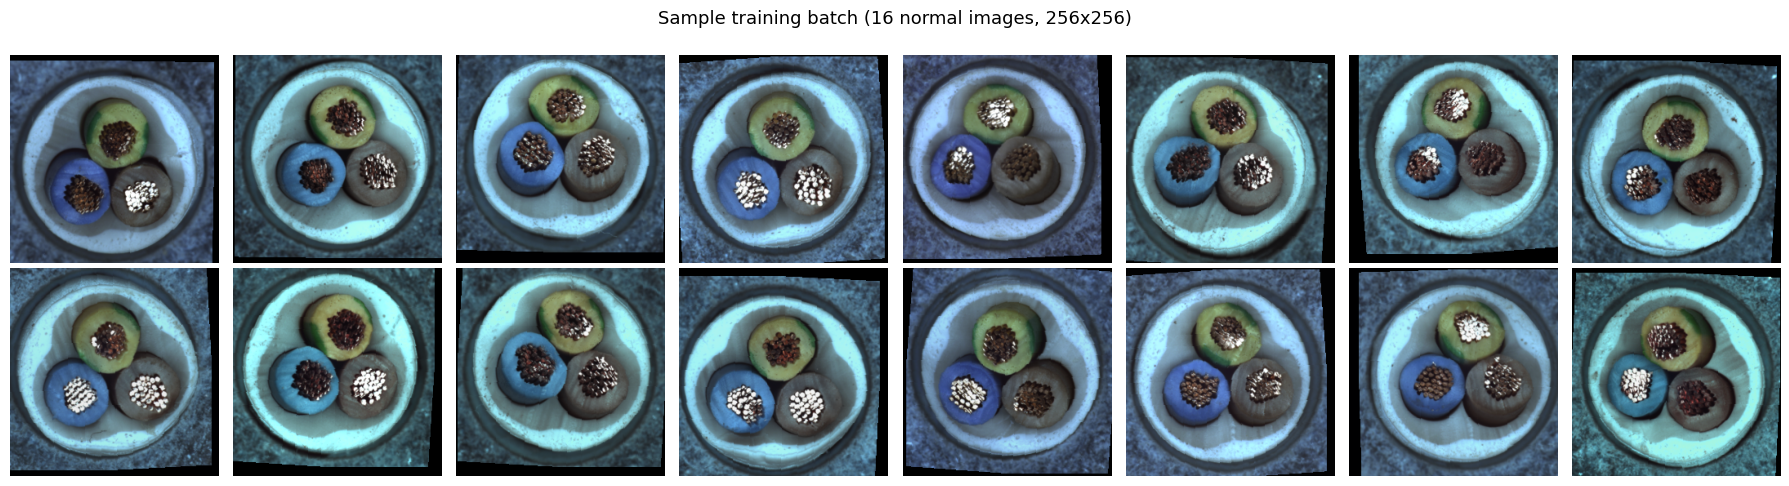

In [4]:
# Visualise a grid of training samples (un-normalised for display)
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406])
IMAGENET_STD  = np.array([0.229, 0.224, 0.225])

def denorm(t):
    """Reverse ImageNet normalisation for display."""
    img = t.permute(1, 2, 0).numpy() * IMAGENET_STD + IMAGENET_MEAN
    return np.clip(img, 0, 1)

fig, axes = plt.subplots(2, 8, figsize=(18, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(denorm(sample_batch[i]))
    ax.axis('off')
fig.suptitle('Sample training batch (16 normal images, 256x256)', fontsize=13)
plt.tight_layout()
plt.show()

## 3. Model Definition & Inspection

In [5]:
model = ConvAutoencoder().to(DEVICE)
print(model)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nTotal parameters    : {total_params:,}')
print(f'Trainable parameters: {trainable_params:,}')

ConvAutoencoder(
  (encoder): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(64, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(

## 4. Forward-Pass Sanity Check

In [6]:
model.eval()
with torch.no_grad():
    x     = sample_batch.to(DEVICE)
    x_hat = model(x)

assert x_hat.shape == x.shape, f'Shape mismatch: {x_hat.shape} != {x.shape}'
print(f'Input  shape : {x.shape}')
print(f'Output shape : {x_hat.shape}')
print('Sanity check passed.')

Input  shape : torch.Size([16, 3, 256, 256])
Output shape : torch.Size([16, 3, 256, 256])
Sanity check passed.


## 5. Training

Train the autoencoder on normal images only using MAE (L1) loss.

In [ ]:
import torch.optim as optim

NUM_EPOCHS = 100  #50
LR         = 1e-2 #1e-3

criterion = torch.nn.L1Loss()  # MAE loss
optimizer = optim.Adam(model.parameters(), lr=LR)

train_losses = []
val_losses   = []

for epoch in range(1, NUM_EPOCHS + 1):
    # --- Train ---
    model.train()
    running_loss = 0.0
    for imgs in train_loader:
        imgs = imgs.to(DEVICE)
        optimizer.zero_grad()
        recon = model(imgs)
        loss  = criterion(recon, imgs)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * imgs.size(0)
    train_loss = running_loss / len(train_loader.dataset)

    # --- Validate ---
    model.eval()
    running_val = 0.0
    with torch.no_grad():
        for imgs in val_loader:
            imgs  = imgs.to(DEVICE)
            recon = model(imgs)
            running_val += criterion(recon, imgs).item() * imgs.size(0)
    val_loss = running_val / len(val_loader.dataset)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    if epoch % 10 == 0 or epoch == 1:
        print(f'Epoch {epoch:3d}/{NUM_EPOCHS}  '
              f'train_loss={train_loss:.6f}  val_loss={val_loss:.6f}')

print('Training complete.')

Epoch   1/50  train_loss=1.121620  val_loss=1.047676
Epoch  10/50  train_loss=0.844815  val_loss=0.743367
Epoch  20/50  train_loss=0.777104  val_loss=0.677054
Epoch  30/50  train_loss=0.752300  val_loss=0.655722
Epoch  40/50  train_loss=0.742589  val_loss=0.653836
Epoch  50/50  train_loss=0.738349  val_loss=0.644620
Training complete.


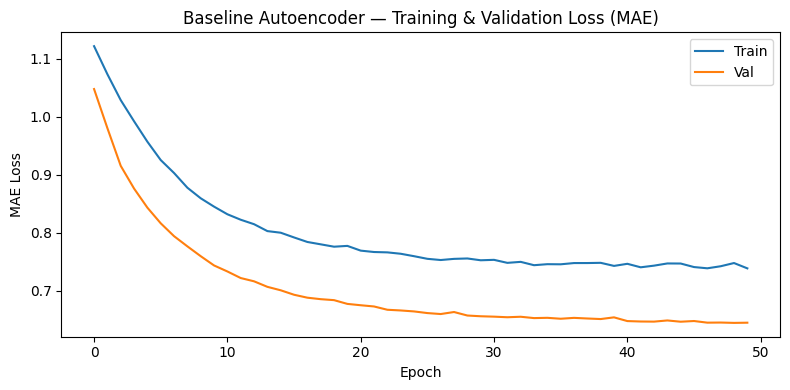

In [8]:
# Loss curves
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label='Train')
plt.plot(val_losses,   label='Val')
plt.xlabel('Epoch')
plt.ylabel('MAE Loss')
plt.title('Baseline Autoencoder — Training & Validation Loss (MAE)')
plt.legend()
plt.tight_layout()
plt.show()

In [9]:
# Save checkpoint
CHECKPOINTS_DIR.mkdir(parents=True, exist_ok=True)
ckpt_path = CHECKPOINTS_DIR / 'baseline_autoencoder.pth'
torch.save(model.state_dict(), ckpt_path)
print(f'Checkpoint saved to {ckpt_path}')

Checkpoint saved to D:\50039-proj-group07-2026\checkpoints\baseline_autoencoder.pth


## 6. Reconstruction Visualisation on Validation Set

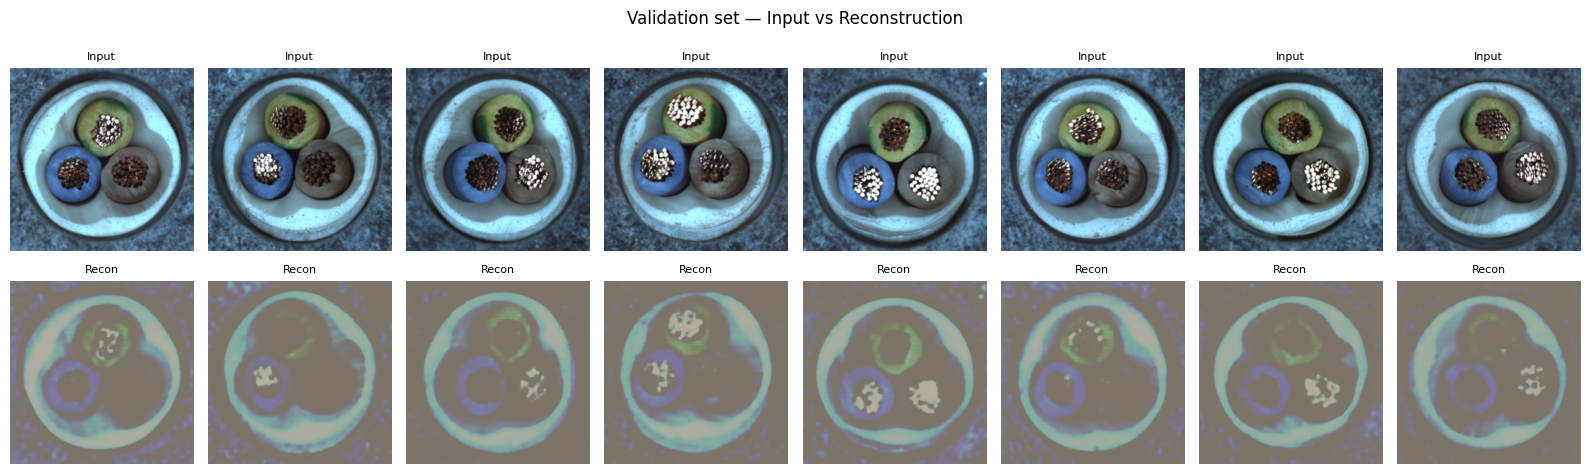

In [10]:
model.eval()
val_batch = next(iter(val_loader)).to(DEVICE)

with torch.no_grad():
    recon_batch = model(val_batch)

n_show = min(8, val_batch.size(0))
fig, axes = plt.subplots(2, n_show, figsize=(2 * n_show, 5))
for i in range(n_show):
    axes[0, i].imshow(denorm(val_batch[i].cpu()))
    axes[0, i].set_title('Input',  fontsize=8)
    axes[0, i].axis('off')
    axes[1, i].imshow(denorm(recon_batch[i].cpu()))
    axes[1, i].set_title('Recon', fontsize=8)
    axes[1, i].axis('off')
fig.suptitle('Validation set — Input vs Reconstruction', fontsize=12)
plt.tight_layout()
plt.show()

## 7. Evaluation on Test Set

The autoencoder was trained on **normal** images only. At inference time, anomalous images should produce higher reconstruction error (MAE) than normal ones. We use the test set — 150 images with binary labels (0 = normal, 1 = anomalous) — to measure actual anomaly-detection performance.

In [11]:
# 7.1 Compute per-image reconstruction error (MAE) on the test set
criterion_eval = torch.nn.L1Loss(reduction='mean')

model.eval()
recon_errors = []
all_labels   = []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(DEVICE)
        recon = model(imgs)
        for i in range(imgs.size(0)):
            err = criterion_eval(recon[i], imgs[i]).item()
            recon_errors.append(err)
        all_labels.extend(labels.tolist())

recon_errors = np.array(recon_errors)
all_labels   = np.array(all_labels)

n_normal = (all_labels == 0).sum()
n_anom   = (all_labels == 1).sum()
print(f'Test set: {n_normal} normal, {n_anom} anomalous')
print(f'MAE — normal  : mean={recon_errors[all_labels==0].mean():.4f}, '
      f'std={recon_errors[all_labels==0].std():.4f}')
print(f'MAE — anomalous: mean={recon_errors[all_labels==1].mean():.4f}, '
      f'std={recon_errors[all_labels==1].std():.4f}')

Test set: 58 normal, 92 anomalous
MAE — normal  : mean=0.6274, std=0.0393
MAE — anomalous: mean=0.6355, std=0.0419


ROC-AUC  : 0.5802
Threshold: 0.6369  (Youden's J)
Precision: 0.7778
Recall   : 0.3804
F1 Score : 0.5109
Accuracy : 0.5533


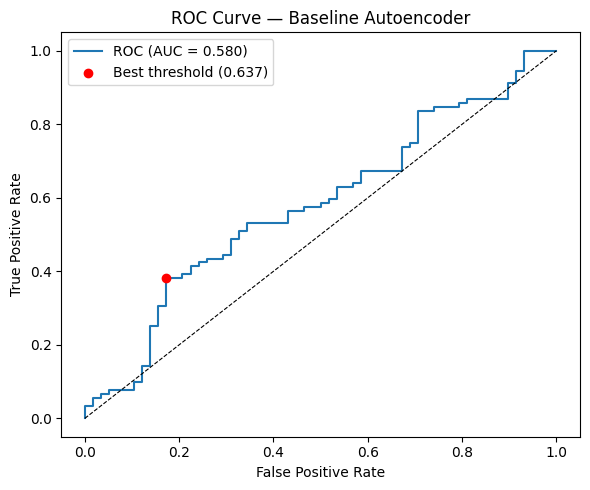

In [12]:
# 7.2 ROC-AUC and classification metrics at the optimal threshold
from sklearn.metrics import (roc_auc_score, roc_curve,
                             precision_score, recall_score,
                             f1_score, accuracy_score)

auc = roc_auc_score(all_labels, recon_errors)
fpr, tpr, thresholds = roc_curve(all_labels, recon_errors)

# Youden's J statistic: maximise TPR - FPR
j_scores = tpr - fpr
best_idx  = np.argmax(j_scores)
best_thr  = thresholds[best_idx]

preds = (recon_errors >= best_thr).astype(int)
prec  = precision_score(all_labels, preds, zero_division=0)
rec   = recall_score(all_labels, preds)
f1    = f1_score(all_labels, preds)
acc   = accuracy_score(all_labels, preds)

print(f'ROC-AUC  : {auc:.4f}')
print(f'Threshold: {best_thr:.4f}  (Youden\'s J)')
print(f'Precision: {prec:.4f}')
print(f'Recall   : {rec:.4f}')
print(f'F1 Score : {f1:.4f}')
print(f'Accuracy : {acc:.4f}')

# Plot ROC curve
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'ROC (AUC = {auc:.3f})')
plt.scatter(fpr[best_idx], tpr[best_idx], color='red', zorder=5,
            label=f'Best threshold ({best_thr:.3f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=0.8)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Baseline Autoencoder')
plt.legend()
plt.tight_layout()
plt.show()

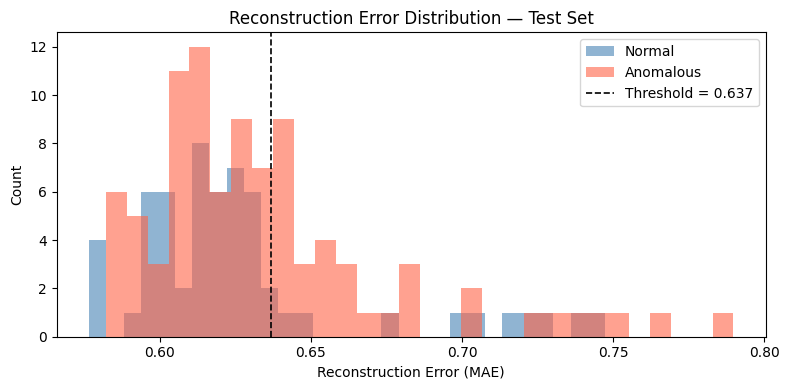

In [13]:
# 7.3 Histogram: reconstruction error distribution (normal vs anomalous)
normal_errors = recon_errors[all_labels == 0]
anom_errors   = recon_errors[all_labels == 1]

plt.figure(figsize=(8, 4))
plt.hist(normal_errors, bins=30, alpha=0.6, label='Normal', color='steelblue')
plt.hist(anom_errors,   bins=30, alpha=0.6, label='Anomalous', color='tomato')
plt.axvline(best_thr, color='black', linestyle='--', linewidth=1.2,
            label=f'Threshold = {best_thr:.3f}')
plt.xlabel('Reconstruction Error (MAE)')
plt.ylabel('Count')
plt.title('Reconstruction Error Distribution — Test Set')
plt.legend()
plt.tight_layout()
plt.show()

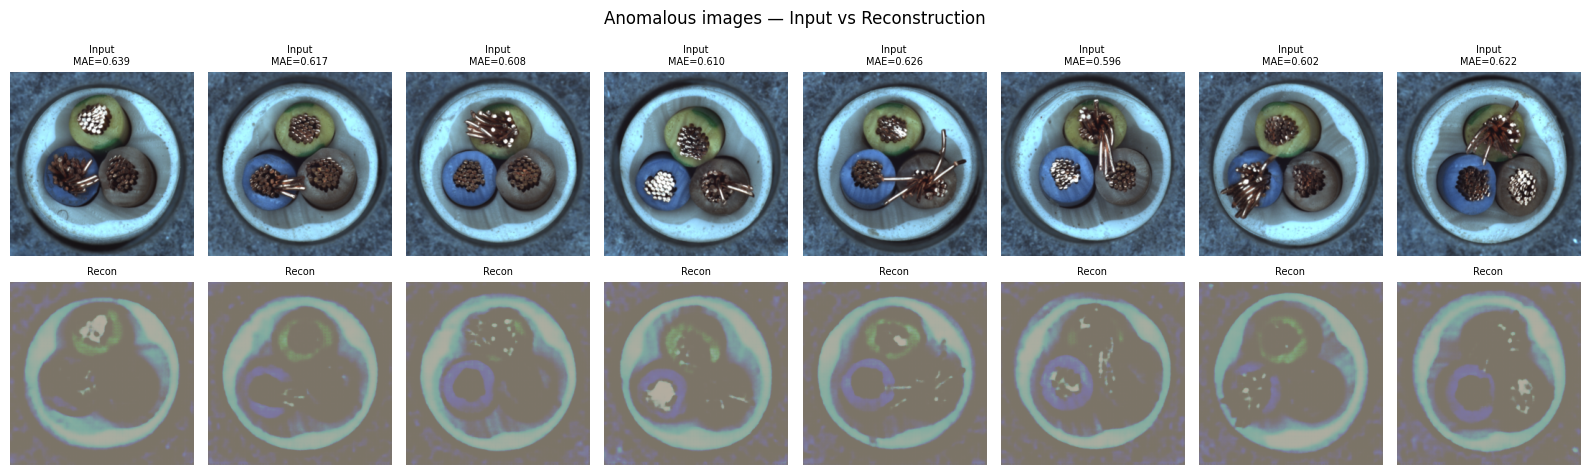

In [14]:
# 7.4 Visualise reconstructions of anomalous images
anom_indices = np.where(all_labels == 1)[0][:8]  # up to 8 anomalous samples

# Collect the images by iterating through test_loader
all_imgs = []
model.eval()
with torch.no_grad():
    for imgs, _ in test_loader:
        all_imgs.append(imgs)
all_imgs = torch.cat(all_imgs, dim=0)  # [N, 3, 256, 256]

anom_imgs  = all_imgs[anom_indices].to(DEVICE)
with torch.no_grad():
    anom_recon = model(anom_imgs)

n_show = len(anom_indices)
fig, axes = plt.subplots(2, n_show, figsize=(2 * n_show, 5))
for i in range(n_show):
    axes[0, i].imshow(denorm(anom_imgs[i].cpu()))
    axes[0, i].set_title(f'Input\nMAE={recon_errors[anom_indices[i]]:.3f}', fontsize=7)
    axes[0, i].axis('off')
    axes[1, i].imshow(denorm(anom_recon[i].cpu()))
    axes[1, i].set_title('Recon', fontsize=7)
    axes[1, i].axis('off')
fig.suptitle('Anomalous images — Input vs Reconstruction', fontsize=12)
plt.tight_layout()
plt.show()